DATASET
Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Preprocessing IMDb reviews...

(a) TRAIN / TEST SPLIT
Training documents: 40000
Testing documents : 10000

TF-IDF train shape: (40000, 50000)
TF-IDF test shape : (10000, 50000)

(c) MULTINOMIAL NAIVE BAYES - TF-IDF
Accuracy    : 0.8813
Precision   : 0.8757
Recall      : 0.8888
F1 Score    : 0.8822

Confusion Matrix:
[[4369  631]
 [ 556 4444]]


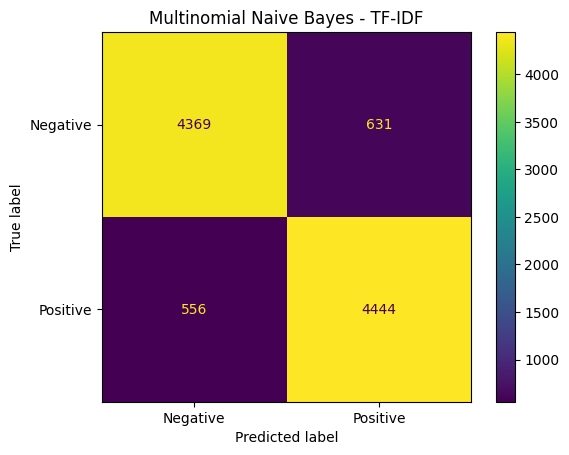


(d) MULTINOMIAL NAIVE BAYES - BAG OF WORDS
Accuracy    : 0.8589
Precision   : 0.8747
Recall      : 0.8378
F1 Score    : 0.8559

(e) MODEL COMPARISON
              Model Features  Accuracy  Precision  F1 Score
        Naive Bayes      BoW    0.8589     0.8747    0.8559
        Naive Bayes   TF-IDF    0.8813     0.8757    0.8822
Logistic Regression      BoW    0.8907     0.8868    0.8913
Logistic Regression   TF-IDF    0.9014     0.8920    0.9026

(f) LOGISTIC REGRESSION vs NAIVE BAYES DISAGREEMENTS
Total disagreements: 815

10 Disagreement Cases:
 Index   Actual LR Prediction  LR Probability NB Prediction  NB Probability
     0 Negative      Positive          0.5019      Negative          0.5080
     1 Negative      Negative          0.5015      Positive          0.6548
    10 Negative      Negative          0.7593      Positive          0.5481
    39 Negative      Negative          0.5296      Positive          0.5288
    63 Positive      Negative          0.6624      Positive        

In [1]:
# ============================================================
# IMDb Sentiment Classification
# Multinomial Naive Bayes vs Logistic Regression
# 
# ============================================================

import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# NLTK resources
# ------------------------------------------------------------

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# ============================================================
# LOAD DATASET
# ============================================================

file_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET")
print("=" * 70)

print("Dataset shape:", df.shape)
print(df.head())


# ============================================================
# PREPROCESSING
# Same preprocessing used in previous IMDb questions
# ============================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove unnecessary characters
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word
        for word in tokens
        if word.isalpha()
        and word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)


print("\nPreprocessing IMDb reviews...")

df["preprocessed_text"] = (
    df["review"]
    .apply(preprocess_text)
)

# Convert labels
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})


# ============================================================
# (a) SAME TRAIN / TEST SPLIT AS Q2
# ============================================================

X = df["preprocessed_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("(a) TRAIN / TEST SPLIT")
print("=" * 70)

print("Training documents:", len(X_train))
print("Testing documents :", len(X_test))


# ============================================================
# TF-IDF FEATURES
# Same representation as Q2: UNIGRAM + BIGRAM
# ============================================================

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)


# ============================================================
# (b) MULTINOMIAL NAIVE BAYES - TF-IDF
# ============================================================

nb_tfidf = MultinomialNB()

nb_tfidf.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb_tfidf = nb_tfidf.predict(
    X_test_tfidf
)


# ============================================================
# (c) NAIVE BAYES TF-IDF METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred
        )
    }


nb_tfidf_metrics = calculate_metrics(
    y_test,
    y_pred_nb_tfidf
)

print("\n" + "=" * 70)
print("(c) MULTINOMIAL NAIVE BAYES - TF-IDF")
print("=" * 70)

for metric, value in nb_tfidf_metrics.items():
    print(
        f"{metric:12s}: {value:.4f}"
    )


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_nb_tfidf
)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
).plot()

plt.title(
    "Multinomial Naive Bayes - TF-IDF"
)

plt.show()


# ============================================================
# (d) MULTINOMIAL NAIVE BAYES - BAG OF WORDS
# ============================================================

bow_vectorizer = CountVectorizer(
    max_features=50000
)

X_train_bow = bow_vectorizer.fit_transform(
    X_train
)

X_test_bow = bow_vectorizer.transform(
    X_test
)

nb_bow = MultinomialNB()

nb_bow.fit(
    X_train_bow,
    y_train
)

y_pred_nb_bow = nb_bow.predict(
    X_test_bow
)

nb_bow_metrics = calculate_metrics(
    y_test,
    y_pred_nb_bow
)

print("\n" + "=" * 70)
print("(d) MULTINOMIAL NAIVE BAYES - BAG OF WORDS")
print("=" * 70)

for metric, value in nb_bow_metrics.items():
    print(
        f"{metric:12s}: {value:.4f}"
    )


# ============================================================
# LOGISTIC REGRESSION - TF-IDF
# Used as comparison model
# ============================================================

lr_tfidf = LogisticRegression(
    max_iter=1000
)

lr_tfidf.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr_tfidf = lr_tfidf.predict(
    X_test_tfidf
)

lr_tfidf_metrics = calculate_metrics(
    y_test,
    y_pred_lr_tfidf
)


# ============================================================
# LOGISTIC REGRESSION - BoW
# Additional comparison
# ============================================================

lr_bow = LogisticRegression(
    max_iter=1000
)

lr_bow.fit(
    X_train_bow,
    y_train
)

y_pred_lr_bow = lr_bow.predict(
    X_test_bow
)

lr_bow_metrics = calculate_metrics(
    y_test,
    y_pred_lr_bow
)


# ============================================================
# (e) FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame([

    {
        "Model": "Naive Bayes",
        "Features": "BoW",
        "Accuracy":
            nb_bow_metrics["Accuracy"],
        "Precision":
            nb_bow_metrics["Precision"],
        "F1 Score":
            nb_bow_metrics["F1 Score"]
    },

    {
        "Model": "Naive Bayes",
        "Features": "TF-IDF",
        "Accuracy":
            nb_tfidf_metrics["Accuracy"],
        "Precision":
            nb_tfidf_metrics["Precision"],
        "F1 Score":
            nb_tfidf_metrics["F1 Score"]
    },

    {
        "Model": "Logistic Regression",
        "Features": "BoW",
        "Accuracy":
            lr_bow_metrics["Accuracy"],
        "Precision":
            lr_bow_metrics["Precision"],
        "F1 Score":
            lr_bow_metrics["F1 Score"]
    },

    {
        "Model": "Logistic Regression",
        "Features": "TF-IDF",
        "Accuracy":
            lr_tfidf_metrics["Accuracy"],
        "Precision":
            lr_tfidf_metrics["Precision"],
        "F1 Score":
            lr_tfidf_metrics["F1 Score"]
    }

])

print("\n" + "=" * 70)
print("(e) MODEL COMPARISON")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# (f) FIND 10 REVIEWS WHERE LR AND NB DIFFER
# ============================================================
# Compare Logistic Regression TF-IDF
# against Naive Bayes TF-IDF
# ============================================================

disagreement_mask = (
    y_pred_lr_tfidf
    !=
    y_pred_nb_tfidf
)

disagreement_indices = np.where(
    disagreement_mask
)[0]

print("\n" + "=" * 70)
print("(f) LOGISTIC REGRESSION vs NAIVE BAYES DISAGREEMENTS")
print("=" * 70)

print(
    "Total disagreements:",
    len(disagreement_indices)
)


# Select first 10 disagreements
selected_indices = disagreement_indices[:10]


# ============================================================
# (g) PROBABILITY FOR PREDICTED CLASS
# ============================================================

disagreement_results = []


for idx in selected_indices:

    # Original review
    review = X_test.iloc[idx]

    # Actual label
    actual = y_test.iloc[idx]

    # LR prediction
    lr_prediction = y_pred_lr_tfidf[idx]

    # NB prediction
    nb_prediction = y_pred_nb_tfidf[idx]

    # LR probabilities
    lr_probabilities = (
        lr_tfidf.predict_proba(
            X_test_tfidf[idx]
        )[0]
    )

    # NB probabilities
    nb_probabilities = (
        nb_tfidf.predict_proba(
            X_test_tfidf[idx]
        )[0]
    )

    # Probability assigned to predicted class
    lr_pred_probability = (
        lr_probabilities[lr_prediction]
    )

    nb_pred_probability = (
        nb_probabilities[nb_prediction]
    )

    disagreement_results.append({

        "Index": idx,

        "Actual": (
            "Positive"
            if actual == 1
            else "Negative"
        ),

        "LR Prediction": (
            "Positive"
            if lr_prediction == 1
            else "Negative"
        ),

        "LR Probability": lr_pred_probability,

        "NB Prediction": (
            "Positive"
            if nb_prediction == 1
            else "Negative"
        ),

        "NB Probability": nb_pred_probability,

        "Review": review

    })


disagreement_df = pd.DataFrame(
    disagreement_results
)


print("\n10 Disagreement Cases:")
print(
    disagreement_df[
        [
            "Index",
            "Actual",
            "LR Prediction",
            "LR Probability",
            "NB Prediction",
            "NB Probability"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# DISPLAY THE ACTUAL REVIEWS
# ============================================================

print("\n" + "=" * 70)
print("10 DISAGREEMENT REVIEWS")
print("=" * 70)

for _, row in disagreement_df.iterrows():

    print("\n" + "-" * 70)

    print("Index:", row["Index"])
    print("Actual:", row["Actual"])

    print(
        "Logistic Regression:",
        row["LR Prediction"],
        "| Probability:",
        f"{row['LR Probability']:.4f}"
    )

    print(
        "Naive Bayes:",
        row["NB Prediction"],
        "| Probability:",
        f"{row['NB Probability']:.4f}"
    )

    print("\nReview:")
    print(row["Review"])


# ============================================================
# INVESTIGATE 3 DISAGREEMENT CASES
# ============================================================

print("\n" + "=" * 70)
print("DETAILED ANALYSIS OF 3 DISAGREEMENT CASES")
print("=" * 70)


# Get important LR features
feature_names = tfidf.get_feature_names_out()
lr_coefficients = lr_tfidf.coef_[0]

top_positive_indices = np.argsort(
    lr_coefficients
)[-20:]

top_negative_indices = np.argsort(
    lr_coefficients
)[:20]

positive_features = set(
    feature_names[top_positive_indices]
)

negative_features = set(
    feature_names[top_negative_indices]
)


for case_number, (_, row) in enumerate(
    disagreement_df.head(3).iterrows(),
    start=1
):

    review_text = row["Review"]

    # Transform review to TF-IDF
    review_vector = tfidf.transform(
        [review_text]
    )

    feature_indices = (
        review_vector.nonzero()[1]
    )

    review_features = [
        feature_names[i]
        for i in feature_indices
    ]

    positive_words = [
        word
        for word in review_features
        if word in positive_features
    ]

    negative_words = [
        word
        for word in review_features
        if word in negative_features
    ]

    print("\n" + "-" * 70)

    print(
        f"CASE {case_number}"
    )

    print(
        "Actual sentiment:",
        row["Actual"]
    )

    print(
        "Logistic Regression:",
        row["LR Prediction"],
        f"({row['LR Probability']:.4f})"
    )

    print(
        "Naive Bayes:",
        row["NB Prediction"],
        f"({row['NB Probability']:.4f})"
    )

    print(
        "\nImportant positive features:",
        positive_words[:10]
    )

    print(
        "Important negative features:",
        negative_words[:10]
    )

    print(
        "\nPossible explanation:"
    )

    print(
        "Logistic Regression considers learned feature "
        "weights and can capture the combined influence "
        "of positive and negative words/phrases. "
        "Naive Bayes estimates class probabilities from "
        "feature likelihoods independently, so frequent "
        "class-specific words can have a stronger effect."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print(
    "\nBest model based on F1 Score:"
)

print(
    f"{best_model['Model']} + "
    f"{best_model['Features']}"
)

print(
    f"F1 Score: {best_model['F1 Score']:.4f}"
)

print(
    "\nNaive Bayes TF-IDF F1:",
    f"{nb_tfidf_metrics['F1 Score']:.4f}"
)

print(
    "Naive Bayes BoW F1:",
    f"{nb_bow_metrics['F1 Score']:.4f}"
)

print(
    "Logistic Regression TF-IDF F1:",
    f"{lr_tfidf_metrics['F1 Score']:.4f}"
)

print(
    "Logistic Regression BoW F1:",
    f"{lr_bow_metrics['F1 Score']:.4f}"
)